# importation

In [1]:
# ====== Standard Libraries ======
import os
import re
import glob
import warnings

warnings.filterwarnings("ignore")

# ====== Data Handling & Visualization ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

# ====== Machine Learning (Scikit-learn) ======
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    mean_squared_error
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from sklearn.model_selection import permutation_test_score
from sklearn.metrics import RocCurveDisplay


# fonction

In [2]:
class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_features):
        self.n_features = n_features

    def fit(self, X, y):
        clf = RandomForestClassifier(n_estimators=100, random_state=2024)
        clf.fit(X, y)
        importances = clf.feature_importances_
        self.indices_ = np.argsort(importances)[::-1][:self.n_features]
        return self

    def transform(self, X):
        return X[:, self.indices_]

# step1 on determine la meilleur taille de bin

File : ./dfLung2MZ2Min.csv
File : ./dfLung10MZ2Min.csv
File : ./dfLung0_5MZ2Min.csv


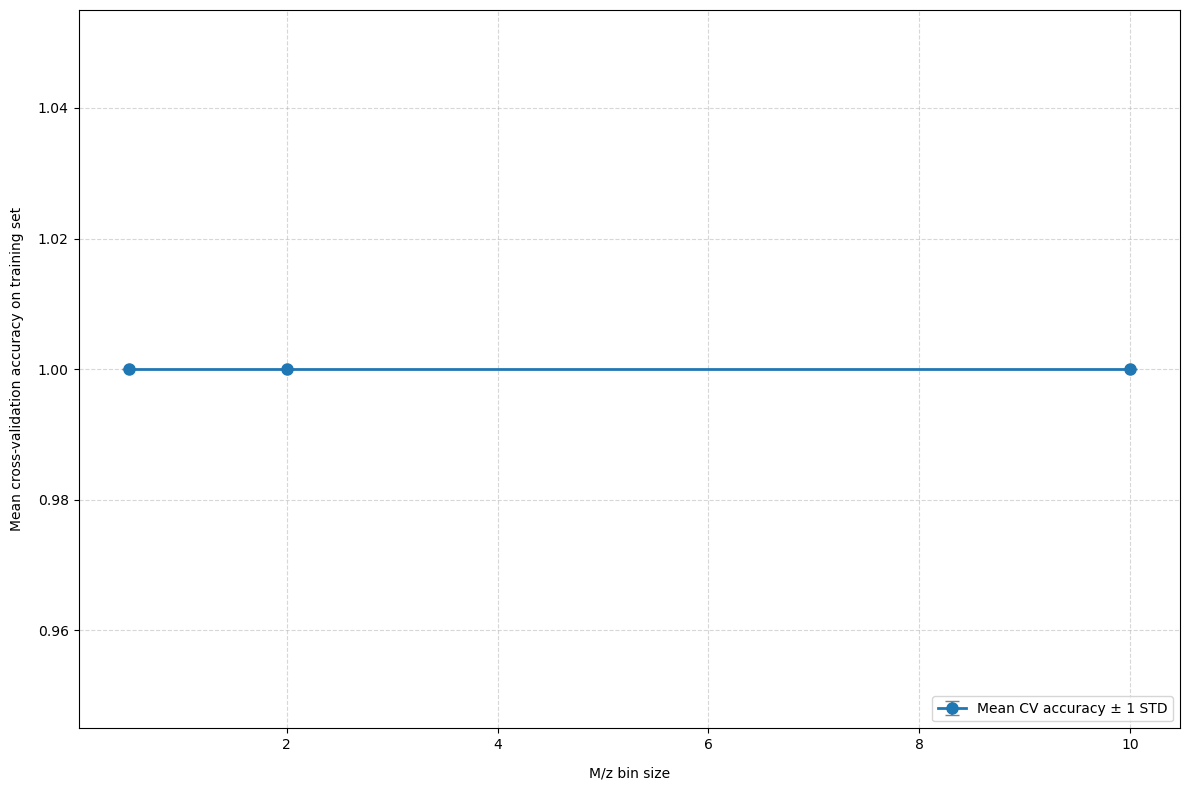

In [ ]:
nbVariable=50
nEstimatorRF=100

results_list = []
for file in ['./dfLung2MZ2Min.csv','./dfLung10MZ2Min.csv','./dfLung0_5MZ2Min.csv']:    
    print(f"File : {file}")
    df = pd.read_pickle(file)
    MTBLS_DIR = os.environ.get("MINUT_DATA_DIR", "data")
    df2=pd.read_csv(os.path.join(MTBLS_DIR, 'a_MTBLS6990_LC-MS_untargeted_positive_reverse-phase_metabolite_profiling.txt'),sep='\t')
    df1=pd.read_csv(os.path.join(MTBLS_DIR, 's_MTBLS6990.txt'),sep='\t')
    df_merged = pd.merge(df1, df2, on="Sample Name", how="inner")
    df_merged=df_merged[df_merged['Characteristics[Organism]']!='blank']
    df_merged=df_merged[['Factor Value[Cohort]','Factor Value[Disease]','Raw Spectral Data File']]
    df['echantillon']=df['echantillon'].apply(lambda x : x.split('/')[-1].split('.')[0])
    df_merged['echantillon']=df_merged['Raw Spectral Data File'].apply(lambda x : x.split('/')[-1].split('.')[0])
    df=pd.merge(df_merged, df, on="echantillon", how="inner")
    df['Factor Value[Cohort]'].unique()
    df['Train/Test']=df['Factor Value[Cohort]'].apply(lambda x : 0 if x=='validation' else 1)
    df=df.dropna()
    df=df[df['Factor Value[Disease]']!='Healthy Control']
    df['categ']=df['Factor Value[Disease]'].apply(lambda x: 0 if x =='Pulmonary Tuberculosis' else 1)
    np.unique(np.array(df['Factor Value[Disease]']),return_counts=True)
    df['categ']=df['Factor Value[Disease]'].apply(lambda x: 0 if x == 'Healthy Control' else 1 if x == 'Pulmonary Tuberculosis' else 2)
    np.unique(np.array(df['categ']),return_counts=True)
    df['batch']=df['batch'].apply(lambda x : x.split('/')[-1].split('.')[0].split('_')[0][3:])
    df['batch'] = df['batch'].astype('category').cat.codes
    a=int(len(df['output_vector'].iloc[0])/3)
    #onlt intensity and mz are keep
    df['output_vector']=df['output_vector'].apply(lambda x : x[:(a+a)])
    train_df = df[df["Train/Test"] == 1].reset_index(drop=True)
    test_df = df[df["Train/Test"] == 0].reset_index(drop=True)
    X_train = np.array([np.array(vec) for vec in train_df['output_vector']])
    X_test = np.array([np.array(vec) for vec in test_df['output_vector']])
    y_train=train_df['categ'].values
    y_test=test_df['categ'].values
    pipeline = Pipeline([
    ('feature_selection', TopFeatureSelector(n_features=nbVariable)),
    ('classification', RandomForestClassifier(n_estimators=100, random_state=1791))
    ]) 
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    mean_cv_score = scores.mean()
    std_cv_score = scores.std()  
    results_list.append({
        'Fichier': file,
        'Accuracy': mean_cv_score,
        'std': std_cv_score
    })
results_df = pd.DataFrame(results_list)
results_df['mz_size']=results_df['Fichier'].apply(lambda x : 10 if '10' in x else 2 if '2MZ' in x else 0.5)
grouped = results_df.groupby('mz_size').agg({
    'Accuracy': 'mean',
    'std': 'mean'
}).reset_index().sort_values('mz_size')
plt.figure(figsize=(12, 8))
plt.errorbar(grouped['mz_size'], grouped['Accuracy'],
             yerr=grouped['std'],
             fmt='-o', color='tab:blue', linewidth=2, markersize=8,
             capsize=5, elinewidth=1.5, ecolor='gray',
             label='Mean CV accuracy ± 1 STD')
plt.xlabel('M/z bin size', fontsize=10, labelpad=10)
plt.ylabel('Mean cross-validation accuracy on training set', fontsize=10, labelpad=10)
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Step2 : find the feature number

In [ ]:
df=pd.read_pickle('./dfLung2MZ2Min.csv')
MTBLS_DIR = os.environ.get("MINUT_DATA_DIR", "data")
df2=pd.read_csv(os.path.join(MTBLS_DIR, 'a_MTBLS6990_LC-MS_untargeted_positive_reverse-phase_metabolite_profiling.txt'),sep='\t')
df1=pd.read_csv(os.path.join(MTBLS_DIR, 's_MTBLS6990.txt'),sep='\t')
df_merged = pd.merge(df1, df2, on="Sample Name", how="inner")
df_merged=df_merged[df_merged['Characteristics[Organism]']!='blank']
df_merged=df_merged[['Factor Value[Cohort]','Factor Value[Disease]','Raw Spectral Data File']]
df['echantillon']=df['echantillon'].apply(lambda x : x.split('/')[-1].split('.')[0])
df_merged['echantillon']=df_merged['Raw Spectral Data File'].apply(lambda x : x.split('/')[-1].split('.')[0])
df=pd.merge(df_merged, df, on="echantillon", how="inner")
df['Factor Value[Cohort]'].unique()
df['Train/Test']=df['Factor Value[Cohort]'].apply(lambda x : 0 if x=='validation' else 1)
df=df.dropna()
df=df[df['Factor Value[Disease]']!='Healthy Control']
df['categ']=df['Factor Value[Disease]'].apply(lambda x: 0 if x =='Pulmonary Tuberculosis' else 1)
np.unique(np.array(df['Factor Value[Disease]']),return_counts=True)
df['categ']=df['Factor Value[Disease]'].apply(lambda x: 0 if x == 'Healthy Control' else 1 if x == 'Pulmonary Tuberculosis' else 2)
np.unique(np.array(df['categ']),return_counts=True)
df['batch']=df['batch'].apply(lambda x : x.split('/')[-1].split('.')[0].split('_')[0][3:])
df['batch'] = df['batch'].astype('category').cat.codes
a=int(len(df['output_vector'].iloc[0])/3)
df['output_vector']=df['output_vector'].apply(lambda x : x[:-a])
train_df = df[df["Train/Test"] == 1].reset_index(drop=True)
test_df = df[df["Train/Test"] == 0].reset_index(drop=True)
X_train = np.array([np.array(vec) for vec in train_df['output_vector']])  
X_test = np.array([np.array(vec) for vec in test_df['output_vector']]) 
y_train=train_df['categ'].values
y_test=test_df['categ'].values

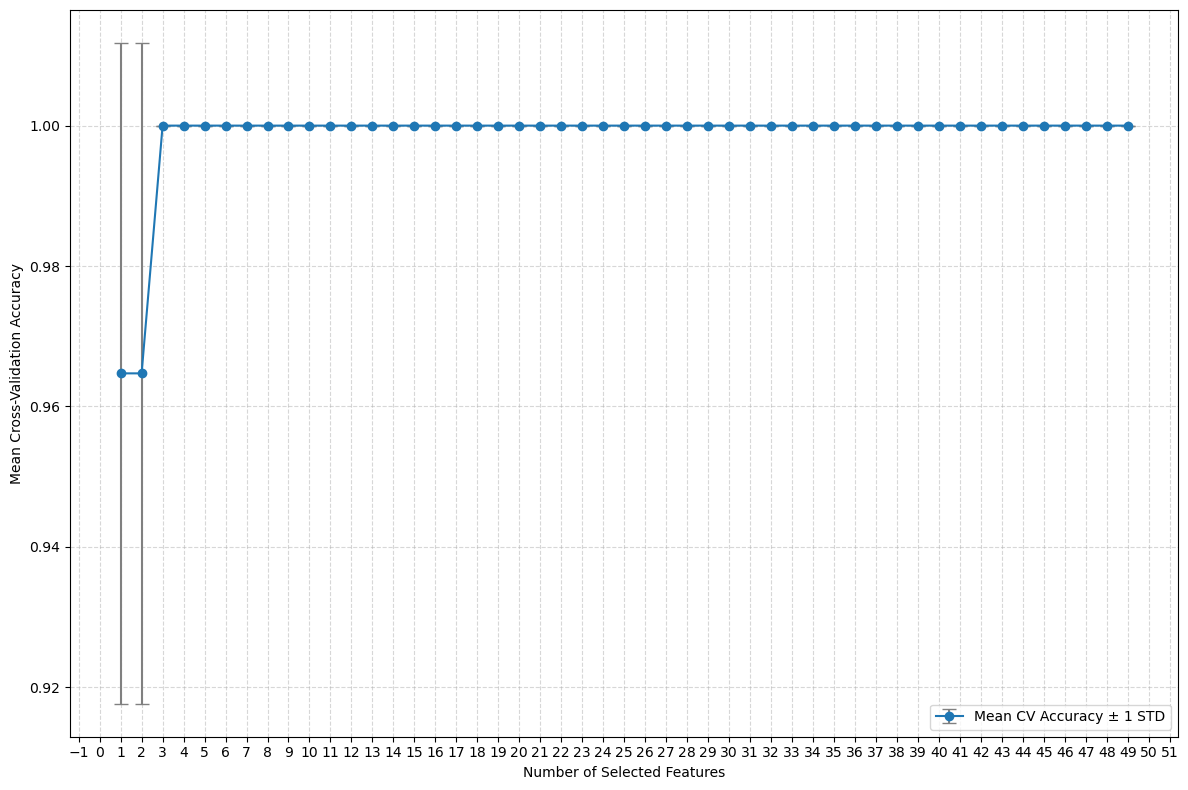

In [5]:
step = 1
max_features = X_train.shape[1]
feature_range = range(step, 50, step)

mean_accuracies = []
std_accuracies = []

for n_features in feature_range:
    pipeline = Pipeline([
    ('feature_selection', TopFeatureSelector(n_features=n_features)),
    ('classification', RandomForestClassifier(n_estimators=100, random_state=1787))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
    mean_accuracies.append(scores.mean())
    std_accuracies.append(scores.std())
plt.figure(figsize=(12, 8))
plt.errorbar(feature_range, mean_accuracies, yerr=std_accuracies,
             fmt='-o', capsize=5, elinewidth=1.5, markersize=6,
             color='tab:blue', ecolor='gray', label='Mean CV Accuracy ± 1 STD')

plt.xlabel('Number of Selected Features', fontsize=10)
plt.ylabel('Mean Cross-Validation Accuracy', fontsize=10)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.tight_layout()
plt.show()


# STEP3: train model

In [6]:
optimalNumberOfFeature=6

Accuracy : 1.0000
[BOOTSTRAP] STD: 0.0000
[BOOTSTRAP] Mean accuracy: 1.0000
[BOOTSTRAP] 95% CI: [1.0000, 1.0000]
[PERMUTATION] p-value: 0.0099
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        63
           2       1.00      1.00      1.00        88

    accuracy                           1.00       151
   macro avg       1.00      1.00      1.00       151
weighted avg       1.00      1.00      1.00       151

[[63  0]
 [ 0 88]]
AUC: 1.0000


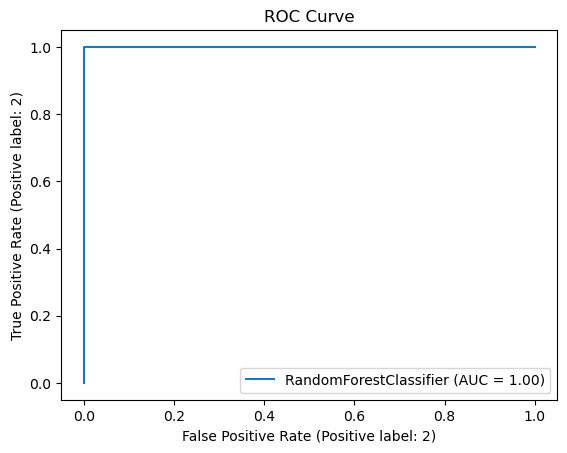

Cross-validated accuracy: 0.9889 ± 0.0333


In [7]:
clf = RandomForestClassifier(n_estimators=100, random_state=2024)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
threshold = importances[sorted_indices[optimalNumberOfFeature]]
selector = SelectFromModel(clf, threshold=threshold, prefit=True)
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)
rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_reduced.fit(X_train_reduced, y_train)
importances2 = rf_reduced.feature_importances_
y_pred = rf_reduced.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

n_iterations = 1000
n_size = len(X_test_reduced)
boot_accuracies = []

for i in range(n_iterations):
    X_sample, y_sample = resample(X_test_reduced, y_test, n_samples=n_size, random_state=i)
    y_pred_sample = rf_reduced.predict(X_sample)
    acc = accuracy_score(y_sample, y_pred_sample)
    boot_accuracies.append(acc)

boot_accuracies = np.array(boot_accuracies)
mean_acc = boot_accuracies.mean()
ci_lower = np.percentile(boot_accuracies, 2.5)
ci_upper = np.percentile(boot_accuracies, 97.5)
std_acc = boot_accuracies.std() 

print(f"[BOOTSTRAP] STD: {std_acc:.4f}")
print(f"[BOOTSTRAP] Mean accuracy: {mean_acc:.4f}")
print(f"[BOOTSTRAP] 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

score, perm_scores, pvalue = permutation_test_score(
    rf_reduced,
    X_test_reduced,
    y_test,
    cv=5,
    n_permutations=100,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42
)

print(f"[PERMUTATION] p-value: {pvalue:.4f}")

print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

y_proba = rf_reduced.predict_proba(X_test_reduced)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc:.4f}")

RocCurveDisplay.from_estimator(rf_reduced, X_test_reduced, y_test)
plt.title("ROC Curve")
plt.show()
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('feature_selection', TopFeatureSelector(n_features=optimalNumberOfFeature)),
    ('classification', RandomForestClassifier(n_estimators=100, random_state=2024))
    ])

scores = cross_val_score(pipeline, X_train, y_train, cv=10)
print(f"Cross-validated accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


In [8]:
clf = RandomForestClassifier(n_estimators=1000, random_state=0)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
threshold = importances[sorted_indices[optimalNumberOfFeature]] 
selector = SelectFromModel(clf, threshold=threshold, prefit=True)
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)
rf_reduced = RandomForestClassifier(n_estimators=100, random_state=0)
rf_reduced.fit(X_train_reduced, y_train)
y_pred = rf_reduced.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)

In [9]:
selectedBin=sorted_indices[:7]

# step4 : analysis

In [10]:
selectedBin

array([3193, 1202,  279, 1380, 2602,  227, 2591], dtype=int64)

In [11]:
# For example, we analyze the bin number 227 (Silybin)
# You can change this value according to the discriminative bin numbers mentioned in the paper.
#
# Note that the vector is composed as follows:
# - first: the intensity values up to a given index a,
# - then: the m/z (mass-to-charge) values,
#
# So, for example, if a < indices_discriminants[1]
# it means that indices_discriminants[1] corresponds to an m/z value.
# Therefore, to plot intensity versus m/z, the user must select:
#   index_2 = indices_discriminants[1] - a

index_1 = 227
index_2 = index_1 + a


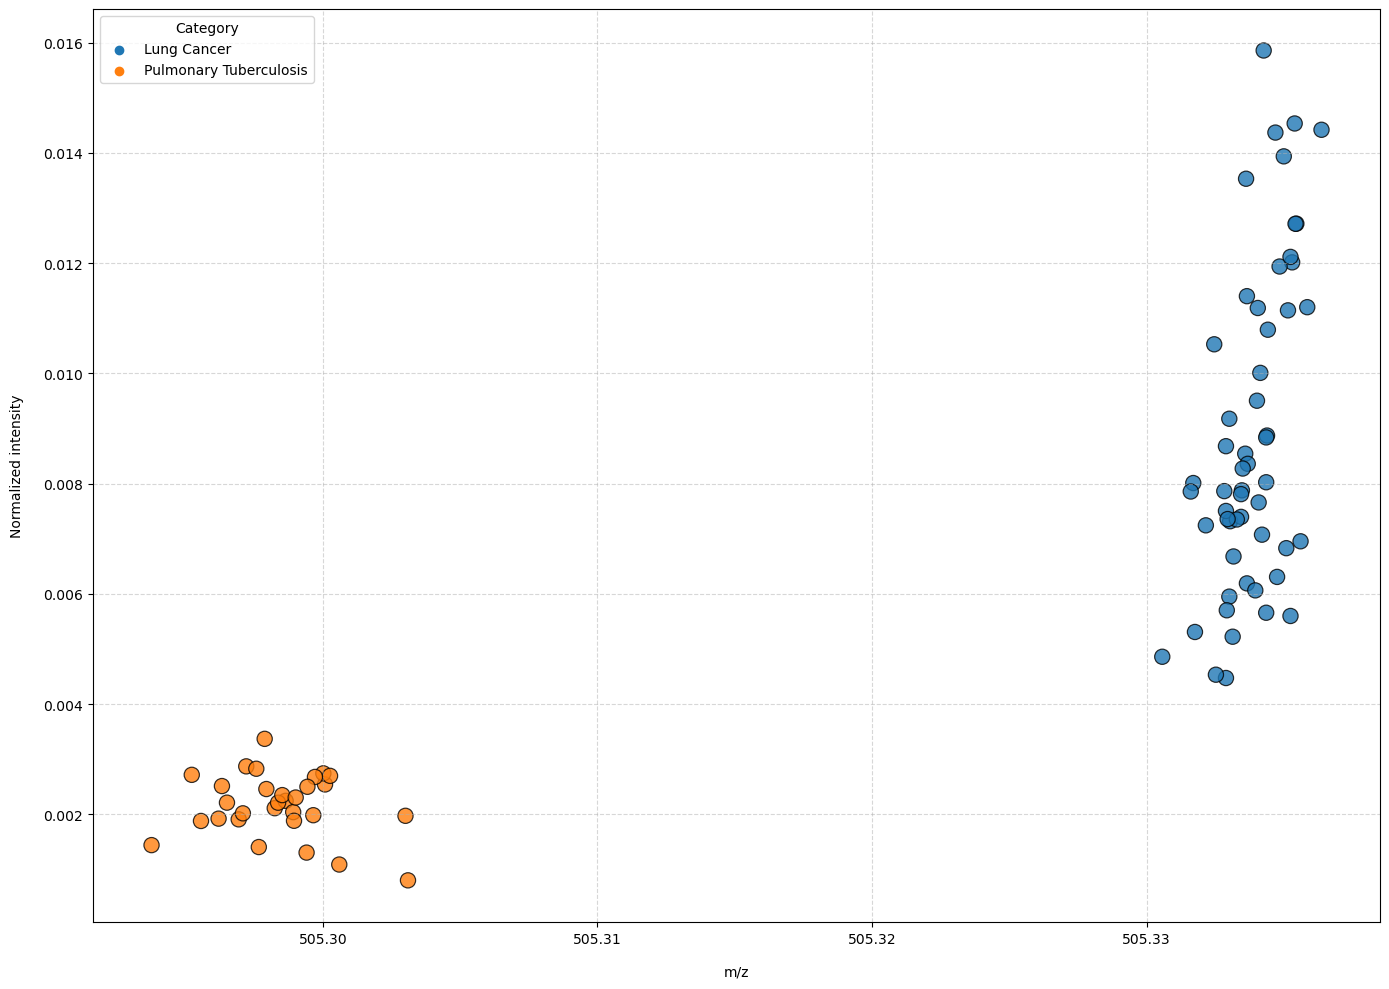

In [12]:
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 10
})


feature_values_1 = [x[index_1] for x in X_train]
feature_values_2 = [x[index_2] for x in X_train]

start_time = 2
end_time = 12
mz_min = 50
mz_max = 1000

feature_values_2 = [(val * (mz_max - mz_min)) + mz_min for val in feature_values_2]

index_1 = 'm/z'
index_2 = 'Normalized intensity'

y_train2 = ['Lung Cancer' if x == 2 else 'Pulmonary Tuberculosis' for x in y_train]

df_plot = pd.DataFrame({
    f'{index_1}': feature_values_2,
    f'{index_2}': feature_values_1,
    'Category': y_train2
})

plt.figure(figsize=(14, 10)) 
scatter = sns.scatterplot(
    data=df_plot,
    x=index_1,
    y=index_2,
    hue='Category',
    palette='tab10',
    s=120,
    edgecolor='k',
    alpha=0.8
)

plt.xlabel(index_1, labelpad=14)
plt.ylabel(index_2, labelpad=14)
plt.legend(title='Category', loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [13]:
data=np.array(feature_values_2)
X = np.array(feature_values_2).reshape(-1, 1)
db = DBSCAN(eps=0.01, min_samples=3).fit(X) 
labels = db.labels_
clusters = {}
for label in np.unique(labels):
    if label == -1:
        continue  # -1 = bruit, on ignore
    cluster_data = data[labels == label]
    mean = np.mean(cluster_data)
    std = np.std(cluster_data)
    std_ppm = (std / mean) * 1e6
    clusters[label] = {
        "count": len(cluster_data),
        "mean": mean,
        "std": std,
        "std_ppm": std_ppm
    }
df2 = pd.DataFrame.from_dict(clusters, orient='index')
df2.index.name = "Cluster"
print(df2)

         count        mean       std   std_ppm
Cluster                                       
0           55  505.333829  0.001181  2.336953
1           30  505.298395  0.002023  4.004079
